# Beyond Last-Click - Notebook 04
## Final Visualisations for Presentation

**Author:** Soheila Zamani

### What this notebook does:
Creates polished, presentation-ready charts for all 4 hypotheses.
All charts are saved to 04_Analysis/

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
import seaborn as sns
import numpy as np
from scipy import stats

# Style — clean and professional
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = 'sans-serif'

print('✅ Libraries loaded')

✅ Libraries loaded


In [4]:
# === FINAL PALETTE: Inferno Hero + Pastel1 Supporting ===
# Inferno amber/gold = the WINNER on every chart (nano, top niche, paid ads)
# Pastel1 soft tones = the supporting cast — quiet, not competing

HERO   = cm.inferno(0.82)   # warm amber/gold  → every winner
P1     = cm.Pastel1(0.08)   # soft pink        → micro
P2     = cm.Pastel1(0.19)   # soft blue        → macro / organic
P3     = cm.Pastel1(0.30)   # soft green       → mega / others
ACCENT = cm.inferno(0.55)   # orange-red       → trend lines / markers
DARK   = '#2C2C2C'          # dark text labels
GRAY   = '#D8D8D8'          # neutral non-highlighted bars

print('✅ Palette ready — Inferno hero + Pastel1 supporting')

✅ Palette ready — Inferno hero + Pastel1 supporting


In [5]:
df_yt = pd.read_csv('../02_Datasets/processed/youtube_influencers_clean.csv')
df_ab = pd.read_csv('../02_Datasets/processed/ab_testing_clean.csv')
df_ab.columns = df_ab.columns.str.strip().str.replace(' ', '_')

print(f'✅ YouTube data: {df_yt.shape[0]:,} rows')
print(f'✅ A/B Testing data: {df_ab.shape[0]:,} rows')

✅ YouTube data: 7,281 rows
✅ A/B Testing data: 588,101 rows


## Chart 1 — H1: Engagement by Influencer Tier

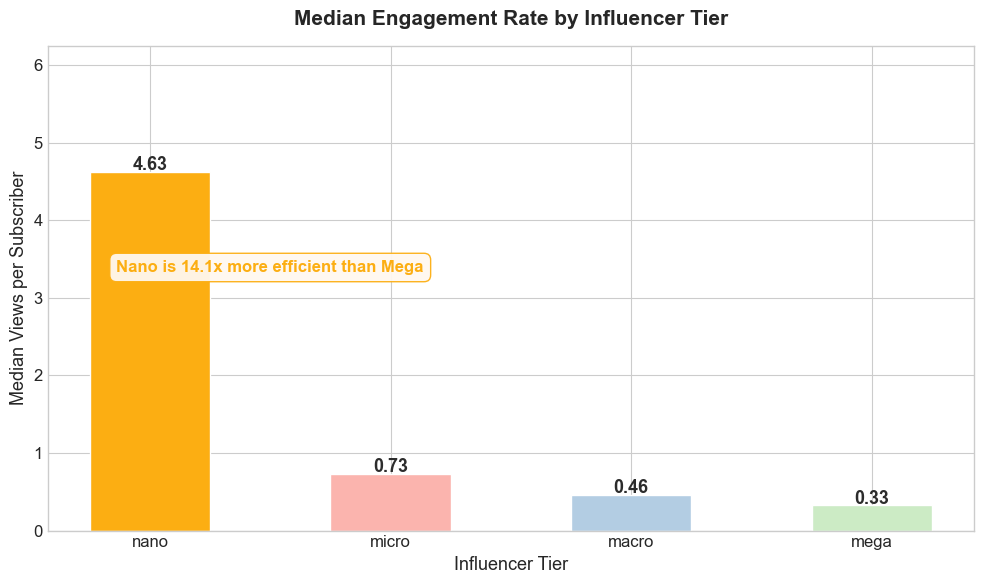

✅ Chart 1 saved


In [6]:
tier_order = ['nano', 'micro', 'macro', 'mega']
colors     = [HERO, P1, P2, P3]

medians = df_yt.groupby('tier')['view_per_subscriber'].median().reindex(tier_order)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(tier_order, medians.values, color=colors, edgecolor='white', width=0.5)

for bar, val in zip(bars, medians.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.2f}', ha='center', fontsize=13, fontweight='bold', color=DARK)

ratio = medians['nano'] / medians['mega']
ax.text(0.5, medians['nano'] * 0.72,
        f'Nano is {ratio:.1f}x more efficient than Mega',
        ha='center', fontsize=12, color=HERO, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#FFF8F0', edgecolor=HERO, alpha=0.95))

ax.set_title('Median Engagement Rate by Influencer Tier', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Influencer Tier', fontsize=13)
ax.set_ylabel('Median Views per Subscriber', fontsize=13)
ax.set_ylim(0, medians.max() * 1.35)

plt.tight_layout()
plt.savefig('../04_Analysis/08_final_h1_tier_engagement.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart 1 saved')

## Chart 2 — H2: Engagement by Niche

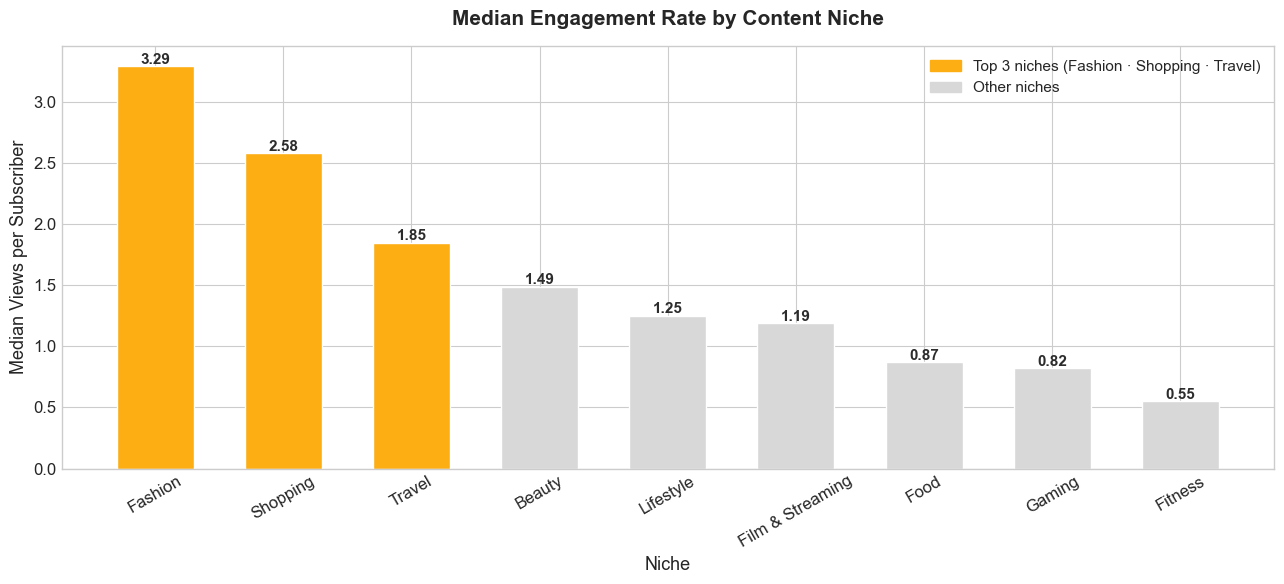

✅ Chart 2 saved


In [7]:
niche_medians = df_yt.groupby('niche')['view_per_subscriber'].median().sort_values(ascending=False)
top3 = ['Fashion', 'Shopping', 'Travel']
niche_colors = [HERO if n in top3 else GRAY for n in niche_medians.index]

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.bar(niche_medians.index, niche_medians.values, color=niche_colors, edgecolor='white', width=0.6)

for bar, val in zip(bars, niche_medians.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.2f}', ha='center', fontsize=11, fontweight='bold', color=DARK)

ax.set_title('Median Engagement Rate by Content Niche', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Niche', fontsize=13)
ax.set_ylabel('Median Views per Subscriber', fontsize=13)
ax.tick_params(axis='x', rotation=30)

highlight = mpatches.Patch(color=HERO, label='Top 3 niches (Fashion · Shopping · Travel)')
normal    = mpatches.Patch(color=GRAY, label='Other niches')
ax.legend(handles=[highlight, normal], fontsize=11)

plt.tight_layout()
plt.savefig('../04_Analysis/09_final_h2_niche_engagement.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart 2 saved')

## Chart 3 — H3: Channel Size vs Engagement Rate

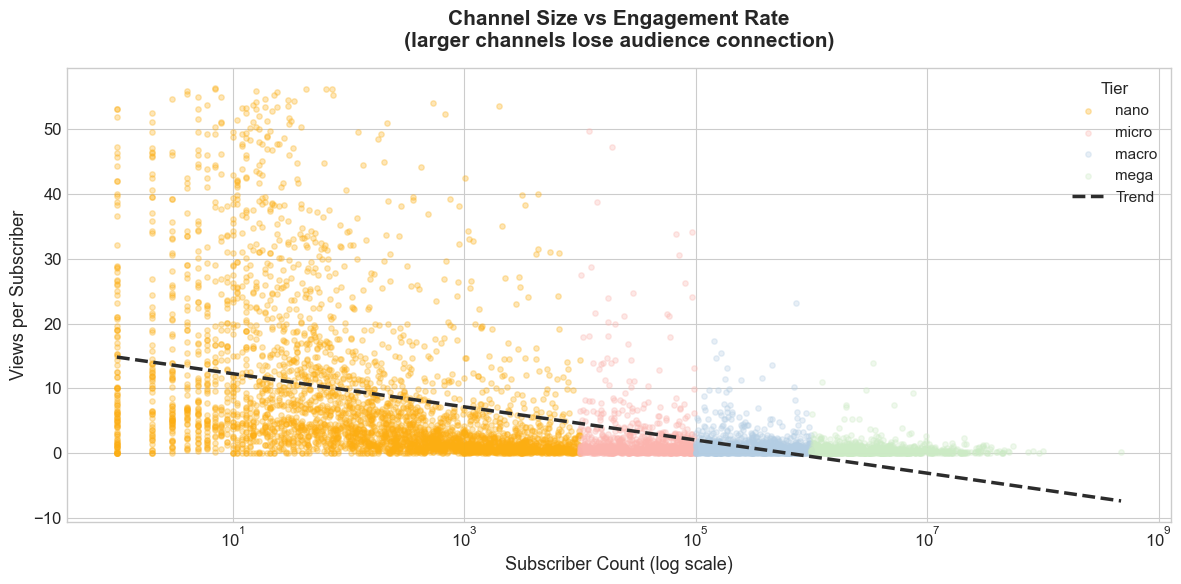

✅ Chart 3 saved


In [8]:
df_plot = df_yt[
    (df_yt['subscribers'] > 0) &
    (df_yt['view_per_subscriber'] < df_yt['view_per_subscriber'].quantile(0.95))
].copy()

tier_colors_map = {'nano': HERO, 'micro': P1, 'macro': P2, 'mega': P3}

fig, ax = plt.subplots(figsize=(12, 6))

for tier in ['nano', 'micro', 'macro', 'mega']:
    mask = df_plot['tier'] == tier
    ax.scatter(df_plot[mask]['subscribers'], df_plot[mask]['view_per_subscriber'],
               alpha=0.3, s=15, color=tier_colors_map[tier], label=tier)

# Log scale — spreads data clearly across all tiers
ax.set_xscale('log')

# Trend line on log scale
log_subs = np.log10(df_plot['subscribers'])
m, b, _, _, _ = stats.linregress(log_subs, df_plot['view_per_subscriber'])
x_range = np.logspace(np.log10(df_plot['subscribers'].min()),
                      np.log10(df_plot['subscribers'].max()), 100)
ax.plot(x_range, m * np.log10(x_range) + b,
        color=DARK, linewidth=2.5, linestyle='--', label='Trend')

ax.set_title('Channel Size vs Engagement Rate\n(larger channels lose audience connection)',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Subscriber Count (log scale)', fontsize=13)
ax.set_ylabel('Views per Subscriber', fontsize=13)
ax.legend(title='Tier', fontsize=11)

plt.tight_layout()
plt.savefig('../04_Analysis/10_final_h3_size_vs_engagement.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart 3 saved')

## Chart 4 — H4: Paid vs Organic Conversion Rate

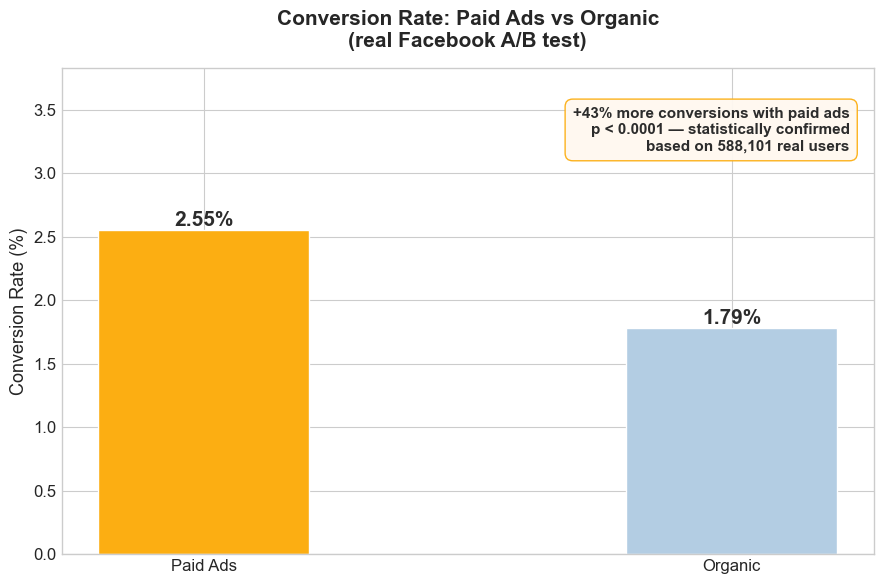

✅ Chart 4 saved


In [9]:
paid_rate    = df_ab[df_ab['test_group'] == 'ad']['converted'].mean() * 100
organic_rate = df_ab[df_ab['test_group'] == 'psa']['converted'].mean() * 100
lift         = ((paid_rate - organic_rate) / organic_rate) * 100

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.bar(['Paid Ads', 'Organic'], [paid_rate, organic_rate],
              color=[HERO, P2], edgecolor='white', width=0.4)

for bar, rate in zip(bars, [paid_rate, organic_rate]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
            f'{rate:.2f}%', ha='center', fontsize=15, fontweight='bold', color=DARK)

ax.text(0.97, 0.92,
        f'+{lift:.0f}% more conversions with paid ads\np < 0.0001 — statistically confirmed\nbased on 588,101 real users',
        transform=ax.transAxes, ha='right', va='top', fontsize=11,
        color=DARK, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#FFF8F0', edgecolor=HERO, alpha=0.95))

ax.set_title('Conversion Rate: Paid Ads vs Organic\n(real Facebook A/B test)',
             fontsize=15, fontweight='bold', pad=15)
ax.set_ylabel('Conversion Rate (%)', fontsize=13)
ax.set_ylim(0, max(paid_rate, organic_rate) * 1.5)

plt.tight_layout()
plt.savefig('../04_Analysis/11_final_h4_paid_vs_organic.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart 4 saved')

## Chart 5 — Bonus: Best Hour to Run Paid Ads

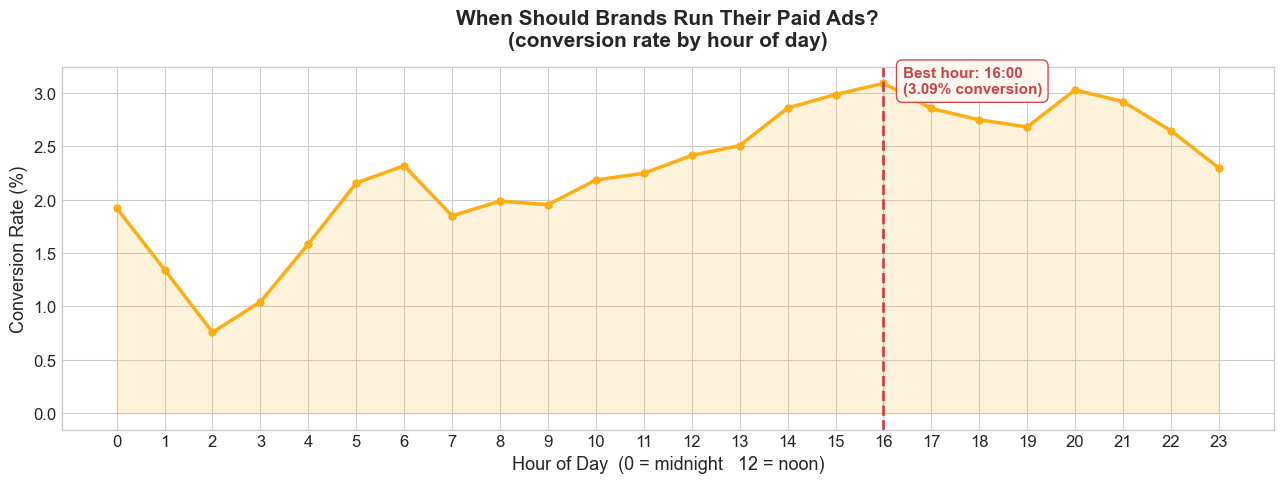

✅ Chart 5 saved — best hour: 16:00


In [10]:
df_ad     = df_ab[df_ab['test_group'] == 'ad']
hour_conv = df_ad.groupby('most_ads_hour')['converted'].mean() * 100
best_hour = hour_conv.idxmax()
best_rate = hour_conv.max()

fig, ax = plt.subplots(figsize=(13, 5))
ax.fill_between(hour_conv.index, hour_conv.values, alpha=0.15, color=HERO)
ax.plot(hour_conv.index, hour_conv.values, color=HERO, linewidth=2.5, marker='o', markersize=5)
ax.axvline(x=best_hour, color=ACCENT, linestyle='--', linewidth=2)

ax.text(best_hour + 0.4, best_rate * 0.97,
        f'Best hour: {best_hour}:00\n({best_rate:.2f}% conversion)',
        fontsize=11, color=ACCENT, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#FFF8F0', edgecolor=ACCENT, alpha=0.95))

ax.set_title('When Should Brands Run Their Paid Ads?\n(conversion rate by hour of day)',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Hour of Day  (0 = midnight   12 = noon)', fontsize=13)
ax.set_ylabel('Conversion Rate (%)', fontsize=13)
ax.set_xticks(range(0, 24))

plt.tight_layout()
plt.savefig('../04_Analysis/12_final_bonus_best_hour.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Chart 5 saved — best hour: {best_hour}:00')

In [11]:
print('=' * 50)
print('NOTEBOOK 04 COMPLETE')
print('=' * 50)
print('''
Charts saved to 04_Analysis/:
  08_final_h1_tier_engagement.png
  09_final_h2_niche_engagement.png
  10_final_h3_size_vs_engagement.png
  11_final_h4_paid_vs_organic.png
  12_final_bonus_best_hour.png

Next: Tableau Dashboard
''')

NOTEBOOK 04 COMPLETE

Charts saved to 04_Analysis/:
  08_final_h1_tier_engagement.png
  09_final_h2_niche_engagement.png
  10_final_h3_size_vs_engagement.png
  11_final_h4_paid_vs_organic.png
  12_final_bonus_best_hour.png

Next: Tableau Dashboard

